In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas_datareader as data_reader
import yfinance as yf
import plotly.graph_objects as go
import plotly.offline as pyo
from datetime import datetime

Initializing the date time and fetching the stock data

In [31]:
end = datetime.now().date()
start = datetime(end.year - 1, end.month, end.day).date()
stock = 'AAPL'

df = yf.download(stock, start, end)

print(f"Default time of data is 1 yr from {end} to {start}")
df.head()

[*********************100%***********************]  1 of 1 completed

Default time of data is 1 yr from 2026-06-25 to 2025-06-25


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-06-25,200.763535,202.865198,199.827247,200.653969,39525700
2025-06-26,200.205750,201.839268,198.671842,200.634043,50799100
2025-06-27,200.285431,202.416974,199.209697,201.092228,73188600
2025-06-30,204.359253,206.570482,198.472603,201.211736,91912800
2025-07-01,206.998795,209.359425,205.325425,205.853330,78788900


In [32]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2025-06-25,200.763535,202.865198,199.827247,200.653969,39525700
1,2025-06-26,200.205750,201.839268,198.671842,200.634043,50799100
2,2025-06-27,200.285431,202.416974,199.209697,201.092228,73188600
3,2025-06-30,204.359253,206.570482,198.472603,201.211736,91912800
4,2025-07-01,206.998795,209.359425,205.325425,205.853330,78788900


Observing the real price of the stock in the form of chart

In [38]:
stock_data = df

pyo.init_notebook_mode(connected=True)

fig = go.Figure(data=[go.Candlestick(
    x=stock_data.index,
    open=stock_data['Open'],
    high=stock_data['High'],
    low=stock_data['Low'],
    close=stock_data['Close'],
    name=f"{stock} price chart",
    increasing_line_color='#26a69a',
    decreasing_line_color='#ef5350'
)])

fig.update_layout(
    template="plotly_white",
    title=dict(text=f'{stock} price', x=0.5, font=dict(size=20)),
    yaxis_title="Price",
    xaxis_title="Date",
    xaxis_rangeslider_visible=False,
    height=650,
    margin=dict(l=50, r=50, t=50, b=50)
)

fig.show()

In [34]:
df = df.drop(['Date'], axis=1)
df.head()

Price,Close,High,Low,Open,Volume
0,200.763535,202.865198,199.827247,200.653969,39525700
1,200.205750,201.839268,198.671842,200.634043,50799100
2,200.285431,202.416974,199.209697,201.092228,73188600
3,204.359253,206.570482,198.472603,201.211736,91912800
4,206.998795,209.359425,205.325425,205.853330,78788900


Observing graph for the close price of the stock

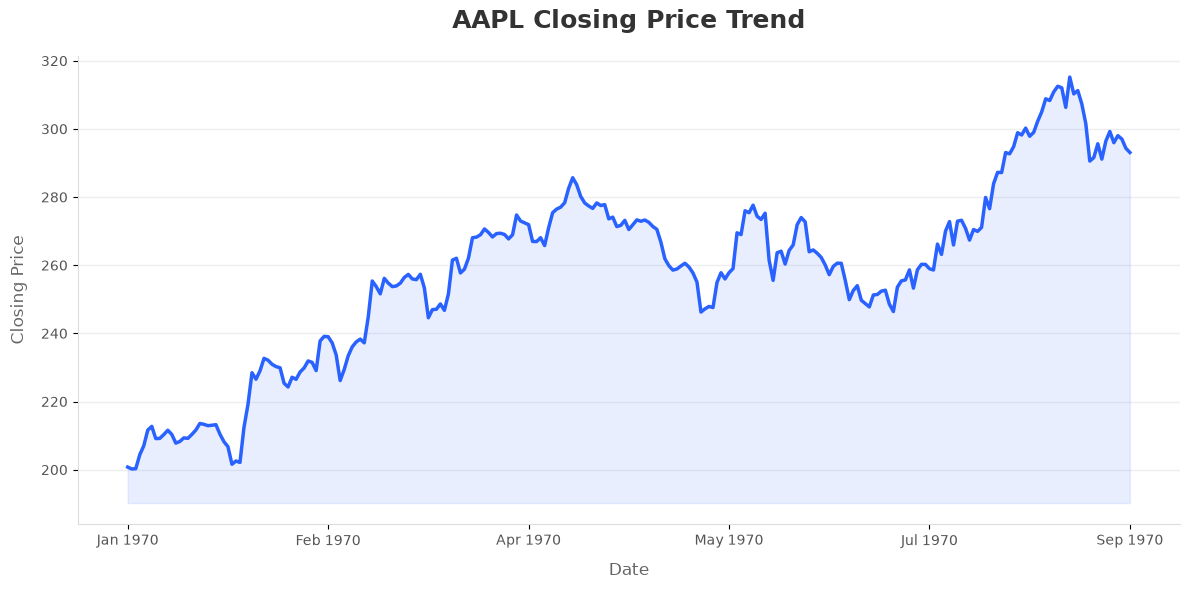

In [ ]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')

ax.plot(df.index, df['Close'], color='#2962ff', linewidth=2.5, label='Close Price')

ax.fill_between(df.index, df['Close'], df['Close'].min() * 0.95, color='#2962ff', alpha=0.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1)
ax.set_axisbelow(True)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # e.g., "Jan 2024"
plt.xticks(rotation=0, color='#555555')
plt.yticks(color='#555555')

plt.title(f'{stock} Closing Price Trend', fontsize=18, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Date', fontsize=12, labelpad=10, color='#666666')
plt.ylabel('Closing Price', fontsize=12, labelpad=10, color='#666666')

plt.tight_layout()
plt.show()